In [1]:
import os
import sys
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import loadtxt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import SGDClassifier, LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import os
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.feature_selection import *
from optuna.integration import OptunaSearchCV
import optuna
import imblearn
import cupy
from cuml import RandomForestClassifier as cuRF
import cudf
import random
import time
%load_ext memory_profiler

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/cudf/utils/gpu_utils.py:162: UserWarning: No NVIDIA GPU detected
  warnings.warn("No NVIDIA GPU detected")


In [ ]:
dataset_druggable = pd.read_csv("../input/combined_DepMap_21Q3_druggable.csv")
dataset_ccle = pd.read_csv("../input/combined_DepMap_21Q3_CCLE_expression.csv")
druggable_X = dataset_druggable.iloc[:, 1:-4686]
druggable_y = dataset_druggable.iloc[:, -4686:]
ccle_X = dataset_ccle.iloc[:, 1:-4686]
ccle = dataset_ccle.iloc[:, -4686:]


: 

In [ ]:
'BRD-A25004090-001-08-4::2.5::HTS'

In [2]:
dataset = pd.read_csv("../input/combined_DepMap_21Q3.csv")
num_gene = 17651
drug_X = dataset.iloc[:, 1:num_gene+1]
drug_y = dataset.iloc[:, -4686:]
drug_list = drug_y.columns.tolist()

In [7]:
import lightgbm as LGB

In [4]:
X_train, X_test, y_train, y_test = train_test_split(drug_X, drug_y['BRD-A25004090-001-08-4::2.5::HTS'], test_size=0.2, random_state=20)

In [123]:

from sklearn.base import clone
kfold_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
wired_params = {'max_depth': 121, 'min_child_samples': 14, 'min_child_weight': 3.186667648998791, 'num_leaves': 283, 'subsample': 0.9536148394560624, 'scale_pos_weight': 8.844210722312107}
new_lgb  = Pipeline([
  ('classifier', LGBMClassifier(n_jobs = 8, is_unbalance = False, verbose = -1, n_estimators = 1000, subsample_freq=1, **wired_params))])
fit_params = {'classifier__eval_set':[(X_test, y_test)], 'classifier__eval_metric' :'average_precision', 'classifier__callbacks': [lgbm.early_stopping(stopping_rounds=100)]}

In [111]:
def custom_cv():
    for fold_idx, (train_idx, test_idx) in enumerate(kfold_outer.split(X_train, y_train)):
        # Clone the estimator for this fold
        estimator_fold = clone(new_lgb)
        if hasattr(X_train, 'iloc'):  # pandas DataFrame
            X_train0, X_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        else:  # numpy array
            X_train0, X_test = X_train[train_idx], X_train[test_idx]
        if y_train is not None:
            if hasattr(y_train, 'iloc'):  # pandas Series
                y_train0, y_test = y_train.iloc[train_idx], y_train.iloc[test_idx]
            else:  # numpy array
                y_train0, y_test = y_train[train_idx], y_train[test_idx]
        estimator_fold.fit(X_train0, y_train0, **fit_params)

In [126]:
sys.path.append('../')
from scripts.cross_validation_utils_ import outer_cross_validate

In [127]:
outer_cross_validate(new_lgb, X_train, y_train, kfold_outer, scoring = 'average_precision', **fit_params)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4]	valid_0's average_precision: 0.434254	valid_0's binary_logloss: 0.516278
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[287]	valid_0's average_precision: 0.53529	valid_0's binary_logloss: 0.505614
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[173]	valid_0's average_precision: 0.559442	valid_0's binary_logloss: 0.463861
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[89]	valid_0's average_precision: 0.469783	valid_0's binary_logloss: 0.512481
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[121]	valid_0's average_precision: 0.679935	valid_0's binary_logloss: 0.392451


{'test_average_precision': array([0.49254498, 0.4779428 , 0.53606417, 0.56444735, 0.56454216]),
 'fit_time': array([13.28250551, 17.16784406, 15.96538806, 14.60326219, 15.40419412]),
 'score_time': array([0.0315268 , 0.03261924, 0.03311276, 0.03055596, 0.03256869])}

In [116]:
custom_cv()

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4]	valid_0's average_precision: 0.434254	valid_0's binary_logloss: 0.516278
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[287]	valid_0's average_precision: 0.53529	valid_0's binary_logloss: 0.505614
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[173]	valid_0's average_precision: 0.559442	valid_0's binary_logloss: 0.463861
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[89]	valid_0's average_precision: 0.469783	valid_0's binary_logloss: 0.512481
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[121]	valid_0's average_precision: 0.679935	valid_0's binary_logloss: 0.392451


In [6]:
mlp =  MLPClassifier(hidden_layer_sizes=(100,))

In [123]:
mlp.fit(X_train, y_train)

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

In [20]:
lgbm_search_params= {
        "max_depth": optuna.distributions.IntDistribution(3, 20),
        "min_child_samples": optuna.distributions.IntDistribution(3, 30),
        "min_child_weight": optuna.distributions.IntDistribution(3, 20),
        "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.2),
        "num_leaves": optuna.distributions.IntDistribution(10, 200),
        "subsample": optuna.distributions.FloatDistribution(0.5, 1.0)
}
lgb =  LGBMClassifier(n_jobs=8, is_unbalance = False, verbose = -1, n_estimators = 500,  metric = None, subsample_freq= 1)

search_estimator_best = OptunaSearchCV(
            lgb,
            param_distributions=lgbm_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='average_precision',
            n_jobs=2,
            n_trials=2,
            verbose=2
)

/scratch/ysu13/tmp/ipykernel_619919/728024389.py:11: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  search_estimator_best = OptunaSearchCV(


In [23]:
search_estimator_best.fit(X_train, y_train, **{'eval_set' : [(X_test, y_test)], 
                             'eval_metric' : 'average_precision', 
                             'callbacks' : [LGB.early_stopping(stopping_rounds=100)]})

[I 2025-06-30 12:26:31,838] A new study created in memory with name: no-name-3caa9c36-2a44-4493-93fd-f04edfd5c3ec


Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[19]	valid_0's average_precision: 0.995816
Early stopping, best iteration is:
[19]	valid_0's average_precision: 0.995816


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[31]	valid_0's average_precision: 0.995391
Early stopping, best iteration is:
[31]	valid_0's average_precision: 0.995391


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[5]	valid_0's average_precision: 0.99545
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-06-30 12:26:34,496] Trial 0 finished with value: 0.9721415050764172 and parameters: {'max_depth': 7, 'min_child_samples': 17, 'min_child_weight': 16, 'learning_rate': 0.1038737113870081, 'num_leaves': 187, 'subsample': 0.8213611753838788}. Best is trial 0 with value: 0.9721415050764172.
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-06-30 12:26:34,552] Trial 1 finished with value: 0.9663968922657158 and parameters: {'max_depth': 9, 'min_child_samples': 14, 'min_child_weight': 12, 'learning_rate': 0.17316372050303055, 'num_leaves': 111, 'subsample': 0.7405045582373085}.

Early stopping, best iteration is:
[30]	valid_0's average_precision: 0.996141
Early stopping, best iteration is:
[30]	valid_0's average_precision: 0.996141
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[20]	valid_0's average_precision: 0.996089


OptunaSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
               estimator=LGBMClassifier(is_unbalance=False, metric=None,
                                        n_estimators=500, n_jobs=8,
                                        subsample_freq=1, verbose=-1),
               n_jobs=2, n_trials=2,
               param_distributions={'learning_rate': FloatDistribution(high=0.2, log=False, low=0.01, step=None),
                                    'max_depth': IntDistribution(high=20, log=False, low=3, step=1),
                                    'min_child_samples': IntDistribution(high=30, log=False, low=3, step=1),
                                    'min_child_weight': IntDistribution(high=20, log=False, low=3, step=1),
                                    'num_leaves': IntDistribution(high=200, log=False, low=10, step=1),
                                    'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None)},
               scoring='average_precision', verbose=2)

In [4]:
lgbm_search_params= {
        "max_depth": optuna.distributions.IntDistribution(3, 20),
        "min_child_samples": optuna.distributions.IntDistribution(3, 30),
        "min_child_weight": optuna.distributions.IntDistribution(3, 20),
        "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.2),
        "num_leaves": optuna.distributions.IntDistribution(10, 200),
        "subsample": optuna.distributions.FloatDistribution(0.5, 1.0)
}
lgbm_search_params = {'classifier__' + key: lgbm_search_params[key] for key in lgbm_search_params}
lgb = Pipeline([
  ('classifier', LGBMClassifier(n_jobs=8, is_unbalance = False, verbose = -1, n_estimators = 500,  metric = None, subsample_freq= 1))
])
search_estimator_best = OptunaSearchCV(
            lgb,
            param_distributions=lgbm_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='average_precision',
            n_jobs=2,
            n_trials=2,
            verbose=2
)
def decay_rate(current_round):
  return 0.1 * (0.995 ** current_round) 

def sleep(env):
  if env.iteration % 200 == 0:
    sleep_duration = random.uniform(0.1, 0.2)
    time.sleep(sleep_duration)

def show_val(env):
    """
    A simple custom callback that prints the current iteration and validation score.
    """
    if env.evaluation_result_list:
        # Assuming the first metric on the first validation set
        metric_name = env.evaluation_result_list[0][0]
        metric_value = env.evaluation_result_list[0][2]
        if env.iteration % 300 == 0:
          sleep_duration = random.uniform(0.1, 0.2)
          time.sleep(sleep_duration)
          print(f"Iteration {env.iteration}: {metric_name} = {metric_value:.4f}")
  

/scratch/ysu13/tmp/ipykernel_2251940/1641780662.py:13: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  search_estimator_best = OptunaSearchCV(


In [6]:
ecb = lgb.early_stopping(stopping_rounds=100, first_metric_only=True)

AttributeError: 'Pipeline' object has no attribute 'early_stopping'

In [22]:
from sklearn import datasets
X, y= datasets.make_classification(n_samples=1000, n_features=2000, n_classes=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [9]:
CB_ = {}
def cb_wrapper(env):
    if str(env.model) in CB_:
        CB_[str(env.model)](env)
    else:
        CB_[str(env.model)] = lgbm.early_stopping(stopping_rounds=100, first_metric_only=True)
        CB_[str(env.model)](env)
    #ecb(env)

In [94]:
{a:1}

{LGBMClassifier(is_unbalance=False, learning_rate=0.18606923964646624,
                max_depth=14, metric=None, min_child_samples=3,
                min_child_weight=3, n_estimators=500, n_jobs=8, num_leaves=200,
                subsample=0.7090448368996478, subsample_freq=1, verbose=-1): 1}

In [74]:
a.fit(X_train, y_train, **{'eval_set':[(X_test, y_test)], 
                             'eval_metric' :'average_precision', 
                             'callbacks': [ecb, lgbm.reset_parameter(learning_rate=decay_rate)]})

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[151]	valid_0's average_precision: 0.641694
Evaluated only: average_precision


LGBMClassifier(is_unbalance=False, learning_rate=0.18606923964646624,
               max_depth=14, metric=None, min_child_samples=3,
               min_child_weight=3, n_estimators=500, n_jobs=8, num_leaves=200,
               subsample=0.7090448368996478, subsample_freq=1, verbose=-1)

In [11]:
def test_lgbm():
   return search_estimator_best.fit(X_train, y_train, 
                          **{'classifier__eval_set':[(X_test, y_test)], 
                             'classifier__eval_metric' :'average_precision', 
                             'classifier__callbacks': [cb_wrapper, 
                                                       lgbm.reset_parameter(learning_rate=decay_rate)]})


In [13]:
searcher = test_lgbm()

[I 2025-06-28 18:45:06,865] A new study created in memory with name: no-name-6a76dba0-28d8-43f8-bb00-1893a3d56eab


Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[161]	valid_0's average_precision: 0.583945
Evaluated only: average_precision
Early stopping, best iteration is:
[321]	valid_0's average_precision: 0.641333
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[265]	valid_0's average_precision: 0.526452
Evaluated only: average_precision
Early stopping, best iteration is:
[56]	valid_0's average_precision: 0.474487
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[8]	valid_0's average_precision: 0.58298
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early

[I 2025-06-28 18:45:54,086] Trial 0 finished with value: 0.4316795718773051 and parameters: {'classifier__max_depth': 5, 'classifier__min_child_samples': 21, 'classifier__min_child_weight': 15, 'classifier__learning_rate': 0.057752717729602145, 'classifier__num_leaves': 97, 'classifier__subsample': 0.7139689180810955}. Best is trial 0 with value: 0.4316795718773051.


Early stopping, best iteration is:
[145]	valid_0's average_precision: 0.535686
Evaluated only: average_precision


[I 2025-06-28 18:45:58,959] Trial 1 finished with value: 0.5040879238221392 and parameters: {'classifier__max_depth': 11, 'classifier__min_child_samples': 10, 'classifier__min_child_weight': 7, 'classifier__learning_rate': 0.13522221989641087, 'classifier__num_leaves': 16, 'classifier__subsample': 0.5411991222837278}. Best is trial 1 with value: 0.5040879238221392.


Early stopping, best iteration is:
[239]	valid_0's average_precision: 0.549527
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[154]	valid_0's average_precision: 0.555694
Evaluated only: average_precision


In [67]:
pd.DataFrame(searcher.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score
0,9.027479,0.502929,0.043651,0.002288,0.422571,0.402863,0.474338,0.613424,0.400716,0.462783,0.079857
1,9.093504,0.363170,0.031451,0.001001,0.473572,0.367400,0.449825,0.575933,0.484916,0.470329,0.066918


In [71]:
best= searcher.best_estimator_

In [73]:
a

LGBMClassifier(is_unbalance=False, learning_rate=0.18606923964646624,
               max_depth=14, metric=None, min_child_samples=3,
               min_child_weight=3, n_estimators=500, n_jobs=8, num_leaves=200,
               subsample=0.7090448368996478, subsample_freq=1, verbose=-1)

In [107]:
a.evals_result_['valid_0']['average_precision'][130:150]

[np.float64(0.5985422439226268),
 np.float64(0.5967961659237381),
 np.float64(0.5991603502068986),
 np.float64(0.6085019236577275),
 np.float64(0.6125911096953741),
 np.float64(0.6128998149634415),
 np.float64(0.6161720458423096),
 np.float64(0.6192989495407383),
 np.float64(0.6167762071964145),
 np.float64(0.6132703025576023),
 np.float64(0.6107921082410267),
 np.float64(0.6076796322455962),
 np.float64(0.6113106413425098),
 np.float64(0.6160030405246812),
 np.float64(0.6113415174470306),
 np.float64(0.6088034143773915),
 np.float64(0.6078184650026334),
 np.float64(0.6095214185139679),
 np.float64(0.6083264196783459),
 np.float64(0.6088865930037176)]

In [ ]:
search_estimator_best.

In [9]:
xgb_search_params = {
 	    "max_depth" : optuna.distributions.IntDistribution(5, 200),
 	    "n_estimators" : optuna.distributions.IntDistribution(50, 200),
        "min_child_weight": optuna.distributions.IntDistribution(3, 20),
        "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.2),
        "subsample": optuna.distributions.FloatDistribution(0.5, 1.0)
    }
xgb_search_params= {'classifier__' + key: xgb_search_params[key] for key in xgb_search_params}
xgb = Pipeline([('classifier', XGBClassifier( n_jobs = 16))])
xgb_estimator_best = OptunaSearchCV(
            xgb,
            param_distributions=xgb_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1',
            n_jobs=2,
            n_trials=20,
            verbose=2
)

/scratch/ysu13/tmp/ipykernel_3983261/1844762009.py:10: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  xgb_estimator_best = OptunaSearchCV(


In [ ]:
xgb_estimator_best.fit(X_train, y_train)
best= xgb_estimator_best.best_estimator_

In [18]:
xgb_cpu = Pipeline([('classifier', XGBClassifier( n_jobs = 16, min_child_weight = 10))])
xgb_cpu.fit(X_train, y_train)

Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=10, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=16,
                               num_parallel_tree=None, random_state=None, ...))])

In [27]:
adb = Pipeline([('classifier', AdaBoostClassifier())])
adb.fit(X_train, y_train)

Pipeline(steps=[('classifier', AdaBoostClassifier())])

In [ ]:
xgb_gpu = Pipeline([('classifier', XGBClassifier(  max_depth = 5, device='cuda', tree_method = 'hist'))])
xgb_gpu.fit(X_train, y_train)

In [ ]:
clf.fit(X_train , y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 186, number of negative: 553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.429712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4354814
[LightGBM] [Info] Number of data points in the train set: 739, number of used features: 17651
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.251691 -> initscore=-1.089611
[LightGBM] [Info] Start training from score -1.089611


Pipeline(steps=[('classifier',
                 LGBMClassifier(is_unbalance=True, min_data_in_leaf=10,
                                n_jobs=8))])

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
cu_rf = Pipeline([('classifier', cuRF())])

In [ ]:

skl_rf = Pipeline([('classifier', RandomForestClassifier(n_jobs = 10))])


In [ ]:
sgd = Pipeline([('scaler', StandardScaler(with_mean=False)),
		 ('classifier',SGDClassifier(penalty = 'elasticnet', loss = 'log_loss', n_jobs = 20, class_weight='balanced'))])
search_params = {
   'l1_ratio': optuna.distributions.FloatDistribution(0.0, 0.2),
    'alpha': optuna.distributions.FloatDistribution(5e-3, 5e-2, log=True),
    'max_iter': optuna.distributions.IntDistribution(1000, 2500)
}
optuna_search_params = {
 	    "max_depth" : optuna.distributions.IntDistribution(5, 20),
 	    "n_estimators" : optuna.distributions.IntDistribution(50, 200),
    }
search_params= {'classifier__' + key: search_params[key] for key in search_params}
optuna_search_params = {'classifier__' + key: optuna_search_params[key] for key in optuna_search_params}
search_estimator_best = OptunaSearchCV(
            xgb_cpu,
            param_distributions=optuna_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1',
            n_jobs=4,
            n_trials=20,
            verbose=2
)

In [ ]:
search_estimator_best.fit(X_train, y_train)
best= search_estimator_best.best_estimator_


In [ ]:
search_estimator_best.fit(X_train, y_train)
best= search_estimator_best.best_estimator_


In [124]:
y_pred = mlp.predict_proba(X_test.values)[:,1]
y_pred0 = best.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
aupr_score = average_precision_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [ ]:
best.predict_proba(X_test.values)

In [ ]:
sgd2 = SGDClassifier(penalty = 'elasticnet', random_state=777, loss = 'log_loss', n_jobs = 20, alpha = 0.01, l1_ratio = 0.2, max_iter=5000,class_weight='balanced')
sgd2.fit(X_train, y_train)

In [ ]:
plt.hist(best['classifier'].coef_[0], bins =100)
plt.show()

In [ ]:
pd.DataFrame({'feature': list(X_train.columns),
					'importances': clf['classification'].feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)

In [ ]:
pd.DataFrame({'feature': list(X_train.columns),
					'importances': xgb2['classifier'].feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)

In [ ]:
y_pred = sgd2.predict_proba(X_train)[:,1]
precision, recall, thresholds = precision_recall_curve(y_train, y_pred)
aupr_score = average_precision_score(y_train, y_pred)
fpr, tpr, _ = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)

In [ ]:
from sklearn_evaluation.plot import confusion_matrix, ConfusionMatrix

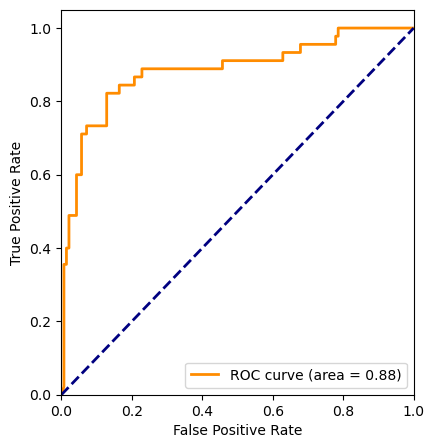

In [128]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

In [ ]:
a.ax_=

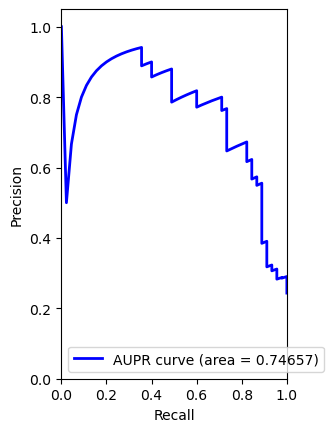

In [127]:
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'AUPR curve (area = {aupr_score:.5f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

In [ ]:
%timeit cross_validate(xgb, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=1)

In [ ]:


%timeit cross_validate(xgb1, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=20)


In [ ]:
xgb2 = XGBClassifier(learning_rate= 0.07297156269889893, max_depth=6, min_child_weight= 1, subsample=0.8042517018984596, n_jobs = 4 )
%timeit cross_validate(xgb2, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=5)


In [ ]:
xgb3 = XGBClassifier(learning_rate= 0.07297156269889893, max_depth=6, min_child_weight= 1, subsample=0.8042517018984596, n_jobs = 15 )
%timeit cross_validate(xgb3, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=5)


In [ ]:
from sklearn.metrics import get_scorer
for s in ['balanced_accuracy', 'precision', 'recall', 'f1', 'average_precision', 'roc_auc']:
    score_ = get_scorer(s)
    print(score_(xgb3, X_test, y_test))

In [ ]:
xgb3.fit(X_train, y_train)

In [ ]:
score_(xgb3, X_test, y_test)

In [ ]:
# SOME PARAMETERS FOR GRIDSEARCH
GRID_SEARCH_PARAM = {
'XGB':{
 	"learning_rate" : [0.05,0.10,0.15,0.20],
 	"max_depth" : [ 3, 4, 5, 6, 8, 10, 12, 15],
 	"min_child_weight" : [ 1, 3, 5, 7 ],
 	"gamma": [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
	 "n_estimators": [50, 100, 200]
},
 'RF':{
	 "n_estimators": [100, 150, 250],
	 "max_depth" : [20, 50, 100, 200],
 },
 'SGD':{
	 'l1_ratio':[0.2, 0.15, 0.1, 0.05],
	 'alpha':[0.02, 0.05]
 }
}

# Basic function to handel sklearn and traditional model training and basic hyperparameter optimization
# TODO refactor this into a class maybe, class DrugModel
def skl_drug_model(X, Y, drug, model = XGBClassifier, oversample = True, fixed_params={}, search_params = {}, search_method = 'gridcv'):

	assert model in [XGBClassifier, RandomForestClassifier, SGDClassifier, LGBMClassifier], f' {model} type not supported'

	
	y = Y[drug]

	 # split X and y into training and testing sets
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)


	if oversample:
		ros = SMOTE(random_state=72)
		X_res, y_res = ros.fit_resample(X_train, y_train)
		oversample = 'oversample'
	else:
		X_res, y_res = X_train, y_train
		oversample = ''


	 # instantiate the classifier
	 

	# k-fold cross validation using multiple metric evaluation
	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
	 #cv_results = cross_validate(xgbc, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1'], n_jobs = 10)
	if oversample:
		imba_pipeline = Pipeline([('sampling', SMOTE(random_state=72)), 
							  ('classifier', model(n_jobs=10, **fixed_params))])
		grid_search_parameters = {'classifier__' + key: search_params[key] for key in search_params}
	else:
		imba_pipeline = model(**fixed_params, n_jobs=20)
		grid_search_parameters = search_params
	 #cross_val_score(imba_pipeline, X_train, y_train, scoring='recall', cv=kf)
	model0 = model(**fixed_params, n_jobs=20)

	 #perform gridsearch if needed
	if search_method == 'gridcv' and search_params:
		grid_imba = HalvingRandomSearchCV(imba_pipeline, param_distributions=grid_search_parameters, cv=kfold, scoring='precision')
		#grid_imba.fit(X_train, y_train) 
		cv_results = cross_validate(grid_imba, X, y, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=10)
		print(cv_results)
		print(grid_imba)
		#return cv_results, grid_imba
		#best_params = {key.removeprefix('classifier__'):grid_imba.best_params_[key] for key in grid_imba.best_params_}
		#print(best_params)
		#model0.set_params(**best_params)
	else:
		cv_results = cross_validate(model0, X_train, y_train, scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold, njobs = 10)
		grid_imba = model0
	 
	if oversample:
		imba_pipeline = Pipeline([('sampling', SMOTE(random_state=72)), 
							  ('classifier', model0)])
	else:
		imba_pipeline = model0
		  
	# generate cross validation results of best model with correct oversampling 
	# OVERSAMPLING must come after validation split for correct validation , thus the use of pipeline
	# cross_validate function will first split into train/validate, then feed training data into pipeline (oversampling + training)
	#cv_results = cross_validate(imba_pipeline, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], n_jobs = 20)
	cv_results = pd.DataFrame(cv_results)
	print(cv_results)

	 # declare parameters
	 

	 # fit the classifier to the training data
	model0.fit(X_res, y_res)

	 # save the trained model
	
		  
	final_results = {
		'best_model': model0,
		'drug': drug,
		'model_class': model,
		'model_search': grid_imba,
		'search_method': search_method,
		'X_test': X_test,
		'Y_test': y_test,
		'X_train': X_train,
		'Y_train': y_train,
		'cv_results':cv_results,
		'oversample': True if oversample else False
	}

	return final_results


def write_drug_model_result(model_results, out_dir):
	 
	model0 = model_results['best_model']
	oversample = 'oversample' if model_results['oversample'] else ''
	drug = model_results['drug']
	model_class = model_results['model_class']

	model_name = {
		  XGBClassifier:'XGBClassifier',
		  RandomForestClassifier:'RandomForestClassifier',
		  SGDClassifier:'SGDClassifier',
		  LGBMClassifier:'LGBMClassifier'

	}[model_class]

	full_out_dir = f'{out_dir}/{oversample}/{drug}/'
	X_test, y_test = model_results['X_test'], model_results['Y_test']
	X_train, y_train = model_results['X_train'], model_results['Y_train']
	y_pred = model0.predict(X_test)

	os.makedirs(full_out_dir, exist_ok=True)

	joblib.dump(model0, f'{full_out_dir}/{model_name}_{drug}.joblib')
	
	model_results['cv_results'].to_csv(f'{full_out_dir}/{model_name}_cv_results_{drug}.csv')

	print(drug,
		 f'{model_class}_model_parameters', model0, "\n",
		 "confusion_matrix:", "\n", confusion_matrix(y_test, y_pred), "\n",
		 file=open(f'{full_out_dir}/{model_name}_confusion_matrix.txt', "a"))

	model_report = classification_report(y_test, y_pred, output_dict=True, labels=np.unique(y_pred))
	model_report = pd.DataFrame(model_report).transpose()
	
	if (model_report.index == "1").any() == True:
		r1 = pd.DataFrame(model_report.loc["1"]).transpose()
		r1.to_csv(f'{full_out_dir}/{model_name}_classification_report_{drug}.csv')
	else:
		print(drug, "Nothing predicted as 1",
			   file=open(f'{out_dir}/{oversample}/{model_name}_classification_report_log.txt', "a"))

	 

	 # feature importance with XGBoost
	if model_class in [XGBClassifier, RandomForestClassifier]:
		fi = pd.DataFrame({'feature': list(X_train.columns),
					'importances': model0.feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)
		fi.to_csv(f'{full_out_dir}/{model_name}_feature_importance_{drug}.csv')

		# plot feature importance
		plt.figure(figsize=(10, 8))
		sns.barplot(x='importances', y='feature', data=fi.head(20))
		plt.title(f'{model_name} Feature Importance for {drug}')
		plt.tight_layout()
		plt.savefig(f'{full_out_dir}/{model_name}_feature_importance_{drug}.png')
		plt.close()
	# save the model report
	model_report.to_csv(f'{full_out_dir}/{model_name}_classification_report_{drug}.csv')
	print(f"Model for {drug} saved to {full_out_dir}/{model_name}_{drug}.joblib")
	return model_results




In [ ]:
model_map = {}
for d in drug_list[0:1]:
	cv_res1, grid_imba1 = skl_drug_model(drug_X, drug_y, d, 
		model = XGBClassifier, 
		oversample = False, 
		fixed_params={},
		search_params=GRID_SEARCH_PARAM['XGB']
	)


In [ ]:
model_map = {}
for d in drug_list[0:1]:
	model_map[d] = skl_drug_model(drug_X, drug_y, d, 
		model = LGBMClassifier, 
		oversample = False,
		search_params={},
		fixed_params={}
		)

In [ ]:
write_drug_model_result(model_map['BRD-A00077618-236-07-6::2.5::HTS'], out_dir = 'output')

In [ ]:
starttime = time.time()
grid_search = skl_drug_model('BRD-A00100033-001-08-9::2.5::HTS',   oversample = True, model = RandomForestClassifier
)
endtime = time.time()